# **COMMENT CATEGORY PREDICTION**

## Problem statement
The goal of his project is to classify user comments into categories based on their content. The dataset contains textual comments along with some numerical features such as upvotes, downvotes and emoticons.

The main challenge in this task is to extract meaningful information from text data and handle the imbalance present in the target classes.

## Objective:
- Analyze the dataset and understand its structure
- Perform preprocessing and feature engineering
- Train multiple machine learning models
- Compare their performance and select the best model
- Generate predictions for the test dataset

# IMPORT FREQUENTLY USED LIBRARIES

In [1]:
import numpy as np 
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# DATA LOADING
The training and test datasets are loaded and their basic structure is examined.

In [2]:
train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

### Dataset shape
checking the number of rows and columns in both datasets.

In [3]:
train.shape, test.shape

((198000, 15), (102000, 14))

### First few rows
helps in understanding the structure of the dataset.

In [4]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


# EXPLORATORY DATA ANALYSIS

In [5]:
#summary of the dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


gives details about data types and non-null values.

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [7]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


## Data Quality Checks
checking for missing values, duplicate entries, and verify data types to ensure the dataset is clean before further processing.

In [8]:
print("Null values in the training data")
train.isnull().sum().sort_values(ascending=False)

Null values in the training data


gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64

In [9]:
#calculate the percentage of missing values
missing_percentage=(train.isna().sum()/len(train))*100
missing_percentage=missing_percentage[missing_percentage>0].sort_values(ascending=False)
print(missing_percentage)

race        73.445960
religion    73.445960
gender      73.445960
comment      0.000505
dtype: float64


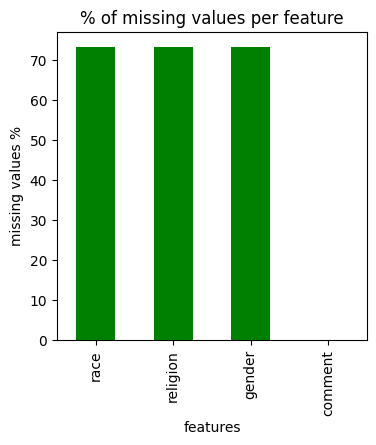

In [11]:
plt.figure(figsize=(4,4))
missing_percentage.plot(kind='bar', color='green')
plt.title('% of missing values per feature')
plt.xlabel('features')
plt.ylabel('missing values %')
plt.show()

the columns 'gender', 'race', and 'religion' contain a large number of missing values i.e. arpund 74%.

these columns could potentially provide additional context but high proportion of missing values makes them difficult to use reliably. handling such a large number of missing values through imputation may introduce bias, so these features are excluded from further analysis.

hence, these columns are not directly relevant to the current modeling approach (which focuses mainly on text and numerical features), they are not used in the model. the main focus is on text-based features and interaction metrics as the comment itself contains the most direct information for classification.

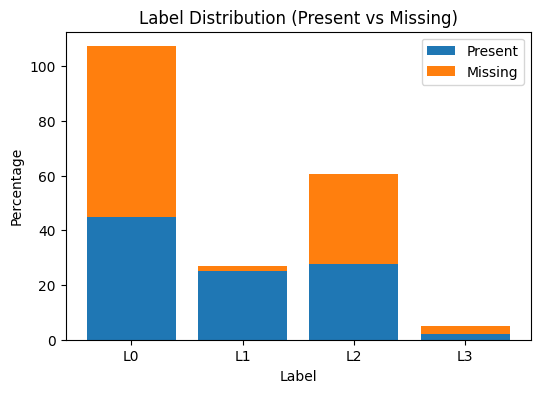

KEY INSIGHT:
When identity is present:
label
0    45.0
1    25.1
2    27.8
3     2.1
Name: proportion, dtype: float64

When identity is missing:
label
0    62.2
1     1.9
2    32.9
3     3.0
Name: proportion, dtype: float64

If Label 1 is higher when identity present,
then identity columns are useful for detecting Label 1


In [12]:
# identity present vs missing

# creating new column (1 = present, 0 = missing)
train['identity_present'] = train['race'].notna().astype(int)

# getting percentage distribution when identity is present
present_data = train[train['identity_present'] == 1]['label']
present_dist = present_data.value_counts(normalize=True).sort_index() * 100

# getting percentage distribution when identity is missing
missing_data = train[train['identity_present'] == 0]['label']
missing_dist = missing_data.value_counts(normalize=True).sort_index() * 100

# creating simple bar plot
plt.figure(figsize=(6, 4))

x = [0, 1, 2, 3]

# plotting both bars (no fancy styling)
plt.bar(x, present_dist.values, label='Present')
plt.bar(x, missing_dist.values, bottom=present_dist.values, label='Missing')

# adding labels
plt.title('Label Distribution (Present vs Missing)')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.xticks(x, ['L0', 'L1', 'L2', 'L3'])

# showing legend
plt.legend()

plt.show()


# printing insights
print("KEY INSIGHT:")

print("When identity is present:")
print(present_dist.round(1))

print("\nWhen identity is missing:")
print(missing_dist.round(1))

print("\nIf Label 1 is higher when identity present,")
print("then identity columns are useful for detecting Label 1")

In [13]:
#handling missing values
train['comment'] = train['comment'].fillna("").astype(str)
test['comment'] = test['comment'].fillna("").astype(str)

the missing values in the comment column are replaced with empty strings to ensure smooth text processing.

In [14]:
# duplicate check
train.duplicated().sum()

np.int64(0)

No duplicate rows found.

In [15]:
# data types
train.dtypes

created_date        object
post_id              int64
emoticon_1           int64
emoticon_2           int64
emoticon_3           int64
upvote               int64
downvote             int64
if_1                 int64
if_2                 int64
race                object
religion            object
gender              object
disability            bool
comment             object
label                int64
identity_present     int64
dtype: object

## Feature Types
features are categorised into numerical and categorical types.

In [16]:
numeric_cols=train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols=train.select_dtypes(include=['object']).columns

numeric_cols, categorical_cols

(Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
        'downvote', 'if_1', 'if_2', 'label', 'identity_present'],
       dtype='object'),
 Index(['created_date', 'race', 'religion', 'gender', 'comment'], dtype='object'))

## Target Variable Analysis
understanding the distribution of the target variable to identify class imbalance.

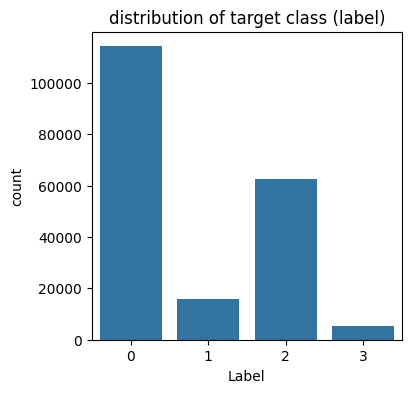

In [18]:
plt.figure(figsize=(4,4))
sns.countplot(x='label', data=train)
plt.title("distribution of target class (label)")
plt.xlabel("Label")
plt.ylabel("count")
plt.show()

The target variable is highly imbalanced, with class 0 having the highest number of samples, while class 3 has very few samples.

This imbalance needs to be considered during model training.

## Numerical Feature Analysis

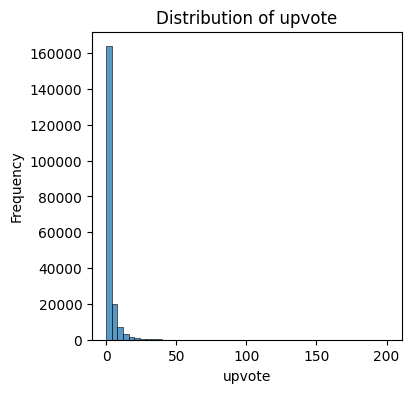

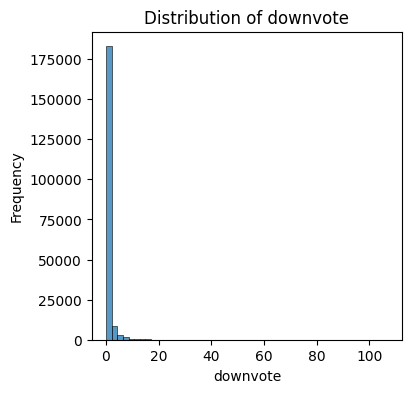

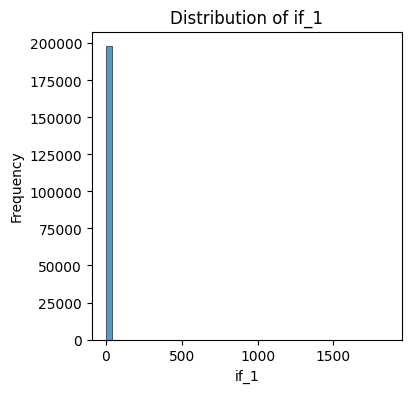

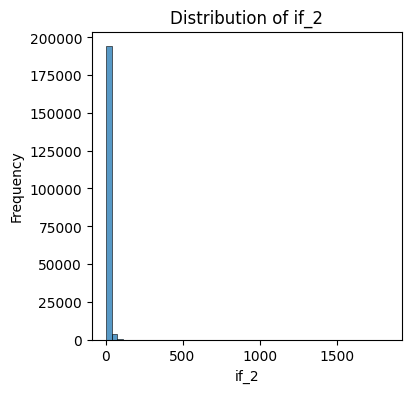

In [19]:
numeric_to_plot = ['upvote', 'downvote', 'if_1', 'if_2']

for col in numeric_to_plot:
    plt.figure(figsize=(4,4))
    sns.histplot(train[col], bins=50, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Most numerical features are highly skewed towards lower values.

A large number of comments have very low interaction (close to zero), while only a small number of comments receive high values. This indicates that user engagement is unevenly distributed across comments.

In [20]:
numeric_cols = ['emoticon_1','emoticon_2','emoticon_3', 'upvote','downvote','if_1','if_2']
mean_by_label = train.groupby('label')[numeric_cols].mean().round(3)
print(mean_by_label.head(50))

       emoticon_1  emoticon_2  emoticon_3  upvote  downvote   if_1    if_2
label                                                                     
0           0.284       0.043       0.108   2.405     0.575  1.298   4.859
1           0.265       0.063       0.150   2.850     0.802  8.012  11.871
2           0.277       0.052       0.136   2.968     0.812  1.530  12.213
3           0.277       0.071       0.134   2.036     0.514  1.129  12.621


if if_1 is strong signal for label 1 , so if if_1 is high -> comment is likey the label 1.

if_2 strongly separates Label 0 from Labels 1,2,3

When if_2 is low (around 4-5) → likely Label 0; 
When if_2 is high (around 10+) → likely Label 1, 2, or 3

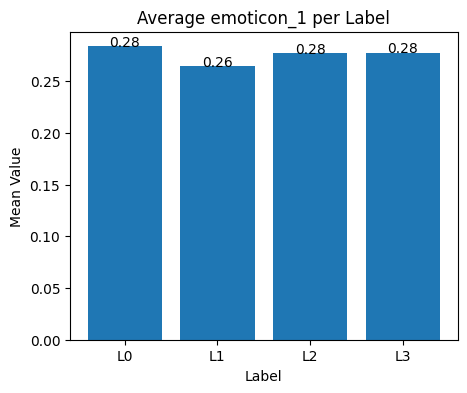

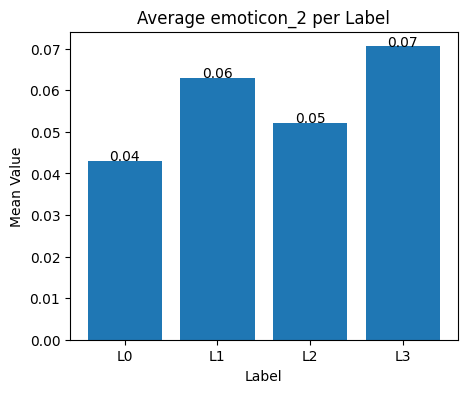

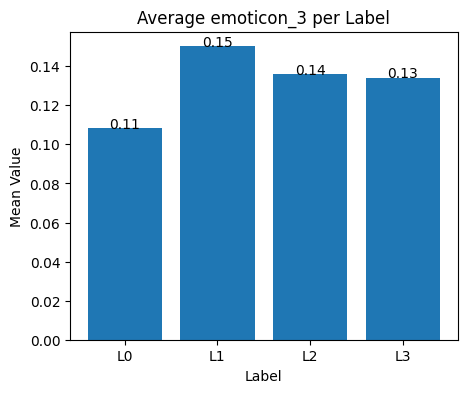

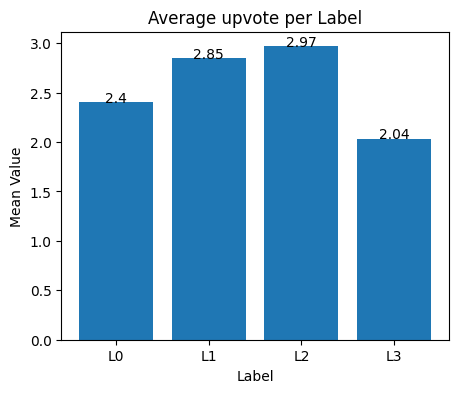

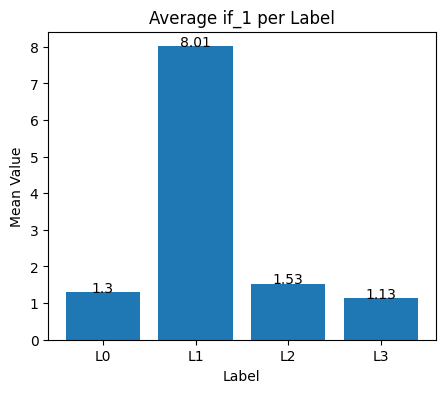

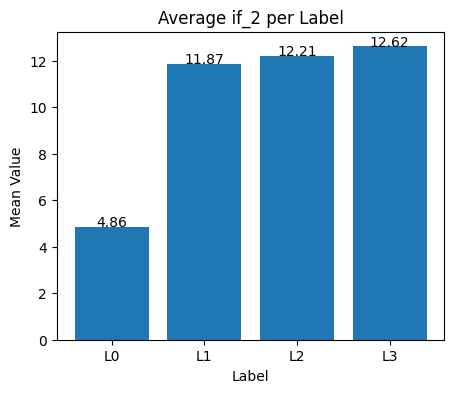

KEY INSIGHTS:
if_1: Label 1 has 8.0 vs others around 1.3 -> Strong signal for Label 1
if_2: Label 0 has 4.8 vs others 11-12 -> Separates Label 0 from rest
emoticons: Very similar across labels -> Weak signal


In [21]:
# numeric features per label

# creating list of numeric columns
numeric_cols = ['emoticon_1','emoticon_2','emoticon_3',
                'upvote','if_1','if_2']

# looping through each column and creating separate simple plots
for col in numeric_cols:
    
    # creating new figure for each feature (simple style)
    plt.figure(figsize=(5, 4))
    
    # calculating average values per label
    mean_vals = train.groupby('label')[col].mean()
    
    # creating bar chart
    plt.bar(
        ['L0','L1','L2','L3'],
        mean_vals.values
    )
    
    # setting simple title and labels
    plt.title('Average ' + col + ' per Label')
    plt.xlabel('Label')
    plt.ylabel('Mean Value')
    
    # adding values on top of bars (simple version)
    for i in range(len(mean_vals.values)):
        val = mean_vals.values[i]
        plt.text(i, val, round(val, 2), ha='center')
    
    # showing plot
    plt.show()


print("KEY INSIGHTS:")
print("if_1: Label 1 has 8.0 vs others around 1.3 -> Strong signal for Label 1")
print("if_2: Label 0 has 4.8 vs others 11-12 -> Separates Label 0 from rest")
print("emoticons: Very similar across labels -> Weak signal")

In [22]:
variation = mean_by_label.max() - mean_by_label.min()
print("FEATURE IMPORTANCE BY VARIATION:")
print(variation.sort_values(ascending=False))

FEATURE IMPORTANCE BY VARIATION:
if_2          7.762
if_1          6.883
upvote        0.932
downvote      0.298
emoticon_3    0.042
emoticon_2    0.028
emoticon_1    0.019
dtype: float64


## Numerical Features vs Target
to analyze how numerical features vary across different classes.

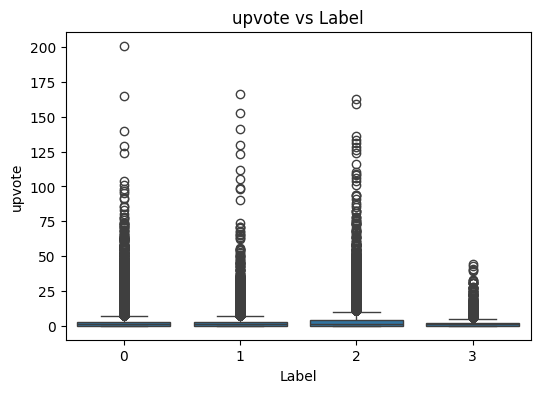

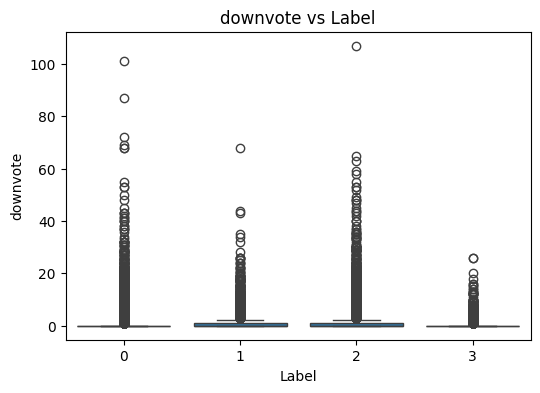

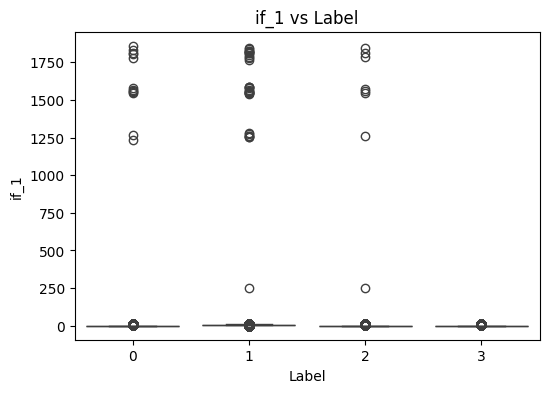

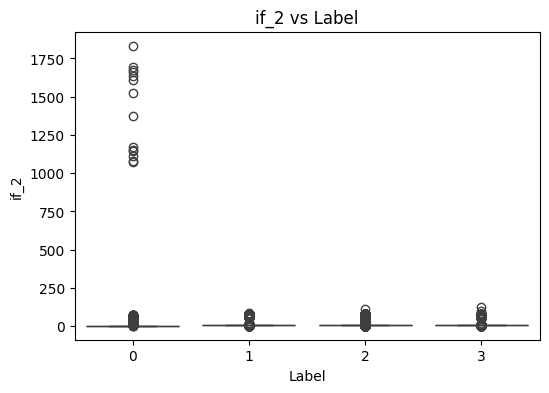

In [23]:
for col in numeric_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=col, data=train)
    plt.title(f"{col} vs Label")
    plt.xlabel("Label")
    plt.ylabel(col)
    plt.show()

most values for upvotes and downvotes are concentrated near zero, with a few extreme outliers.

that means these features are highly skewed and do not clearly separate the classes.

if_1 and if_2, although there are some extreme values, the majority of values overlap across categories.

label has generally fewer interactions and lower spread compared to other classes.

## Text Feature Analysis

In [24]:
train['comment'] = train['comment'].fillna('')

In [25]:
# creating features
train['char_count']= train['comment'].apply(len)
train['word_count']= train['comment'].apply(lambda x: len(x.split()))

In [26]:
stats = train.groupby('label')[['char_count','word_count']].mean().round(1)
print(stats)

       char_count  word_count
label                        
0           295.9        51.2
1           335.7        57.2
2           316.9        54.9
3           194.2        35.0


if char length is lesse than 200 and if the count is less the label must be label 3

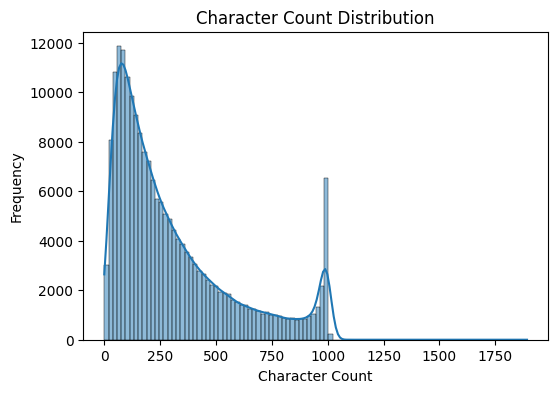

In [27]:
# plotting charcater count distribution 
plt.figure(figsize=(6,4))
sns.histplot(train['char_count'], bins=100, kde=True)
plt.title("Character Count Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

The character count distribution is right-skewed, indicating that most comments are relatively short, while a few comments are very long.

This suggests that comment length varies significantly across the dataset.

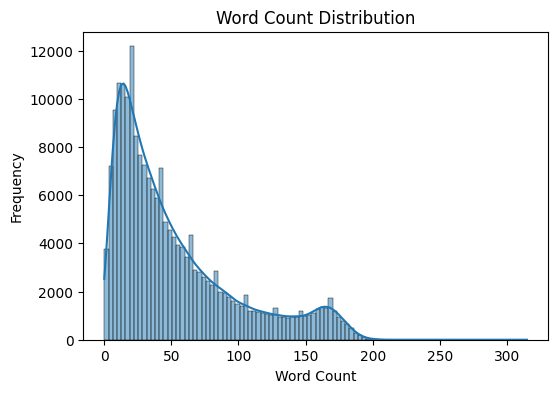

In [28]:
#plotting word count distribution
plt.figure(figsize=(6,4))
sns.histplot(train['word_count'], bins=100, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

The word count distribution follows a similar pattern to character count, with most comments containing a moderate number of words.

Only a small number of comments have very high word counts.

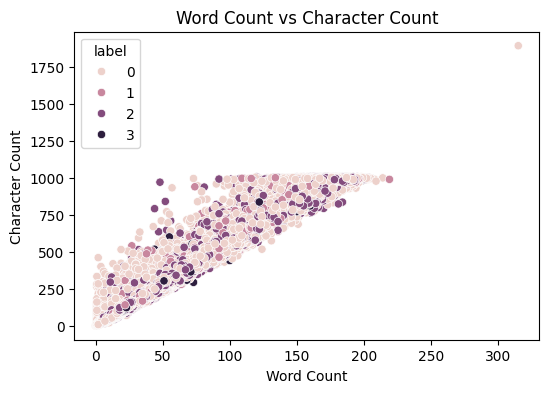

In [29]:
# scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='word_count', y='char_count', data=train, hue='label')
plt.title("Word Count vs Character Count")
plt.xlabel("Word Count")
plt.ylabel("Character Count")
plt.show()

There is a strong positive relationship between word count and character count, which is expected since longer comments contain more words.

The distribution appears similar across different labels, indicating that text length alone may not strongly differentiate between classes.

In [31]:
for label in [0, 1, 2, 3]:
    print(f"LABEL {label}")
    samples = train[train['label']==label]['comment'].dropna().sample(5, random_state=42)
    for i, comment in enumerate(samples, 1):
        print(f"\n[{i}] {str(comment)[:300]}")
        print("-" * 40)

LABEL 0

[1] Was the same stock answer not given when he bailed out Bombardier who executives subsequently aptted themselves on the back with bigger bonuses?
----------------------------------------

[2] Good luck with wi that.
----------------------------------------

[3] You're one to talk about spinning Doc.  Buick USA sales have been increasing, not decreasing over at least the past 6 years, and per the article, it is a niche brand fo GM in the USA.  Countless parts are manufactured in China, even for your beloved Hyundai.  So tell me what vehicles assembled in th
----------------------------------------

[4] everyobdy is a pioneer nowadays.
----------------------------------------

[5] Well, ozd actually, the heightened sensitivity on Anglo-French relations seems to be mainly on your part. That histories lean disproportionately to the victors is fairly common knowledge.
----------------------------------------
LABEL 1

[1] Do the newspapers report the race of a cop who shoots a de

In [ ]:
from collections import Counter
import re

def get_top_words(label_num, top_n=20):
    # getting all comments for this label
    comments = train[train['label'] == label_num]['comment']
    
    # filling missing values
    comments = comments.fillna('')
    
    # joining all text together and converting to lowercase
    all_text = ' '.join(comments)
    all_text = all_text.lower()
    
    # finding words (removing punctuation and keeping words with 4+ letters)
    words = re.findall(r'\b[a-z]{4,}\b', all_text)
    
    # creating stopwords list
    stopwords = {        'this','that','with','have','from','they', 'will','been','were','their','what','when',
        'your','just','about','would','there','which', 'them','then','than','also','into','more',
        'some','could','other','these','those','come'}
    
    # removing stopwords using loop
    filtered_words = []
    for w in words:
        if w not in stopwords:
            filtered_words.append(w)
    
    # updating words list
    words = filtered_words
    
    # counting words
    word_counts = Counter(words)
    
    # getting top results
    top_results = word_counts.most_common(top_n)
    
    return top_results

print("TOP 20 WORDS PER LABEL")

for label in [0, 1, 2, 3]:
    print("\nLabel", label, "top words:")
    
    # getting top words
    top_words = get_top_words(label)
    
    # creating formatted list
    words_only = []
    for word, count in top_words:
        words_only.append(f"{word}({count})")
    
    # printing result
    print("  ", ", ".join(words_only))

In [40]:
#text signals per label
# checking caps, exclamation, urls patterns for each label

print("TEXT SIGNAL PATTERNS PER LABEL")

# creating column for caps (3 or more uppercase letters)
train['has_caps'] = train['comment'].str.contains(r'[A-Z]{3,}')
train['has_caps'] = train['has_caps'].astype(int)

# creating column for exclamation marks
train['has_exclaim'] = train['comment'].str.contains(r'!')
train['has_exclaim'] = train['has_exclaim'].astype(int)

# creating column for question marks
train['has_question'] = train['comment'].str.contains(r'\?')
train['has_question'] = train['has_question'].astype(int)

# creating column for urls
train['has_url'] = train['comment'].str.contains(r'http|www')
train['has_url'] = train['has_url'].astype(int)

# creating column for quotes
train['has_quote'] = train['comment'].str.contains(r'"')
train['has_quote'] = train['has_quote'].astype(int)

# selecting signal columns
signal_columns = ['has_caps', 'has_exclaim', 'has_question', 'has_url', 'has_quote']

# grouping by label and finding average
signals = train.groupby('label')[signal_columns].mean()

# converting to percentage
signals = signals * 100

# rounding values
signals = signals.round(3)

# printing result
print(signals)

TEXT SIGNAL PATTERNS PER LABEL
       has_caps  has_exclaim  has_question  has_url  has_quote
label                                                         
0        22.665       11.539        26.333    3.165     21.641
1        23.828       10.849        31.486    2.331     28.037
2        24.457       14.287        26.481    1.893     23.338
3        15.999       14.079        21.905    0.951     14.536


## Time analysis

In [41]:
# converting created_date to datetime
train['created_date'] = pd.to_datetime(train['created_date'])

# extracting hour
train['hour'] = train['created_date'].dt.hour

# extracting day of week (0 = monday)
train['dayofweek'] = train['created_date'].dt.dayofweek

# extracting month
train['month'] = train['created_date'].dt.month

# selecting useful columns
sample_data = train[['created_date', 'hour', 'dayofweek', 'month']]

# printing first 5 rows
print(sample_data.head())

# creating day names list
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

                      created_date  hour  dayofweek  month
0 2024-01-18 08:43:57.397508+00:00     8          3      1
1 2024-03-24 21:43:11.490017+00:00    21          6      3
2 2024-04-24 20:32:17.014931+00:00    20          2      4
3 2023-05-28 22:00:14.214527+00:00    22          6      5
4 2023-09-09 23:12:05.689498+00:00    23          5      9



HOUR-WISE DISTRIBUTION


--- LABEL: Normal ( 0 ) ---

Raw Counts (Number of comments per hour):
hour
0     6995
1     6570
2     6108
3     5573
4     5254
5     4914
6     4560
7     4075
8     3755
9     3014
10    2464
11    1762
12    1391
13    1158
14    1352
15    2019
16    3169
17    4801
18    6000
19    7331
20    8283
21    8248
22    7977
23    7400
dtype: int64

Percentage Distribution:
hour
0     6.126667
1     5.754425
2     5.349776
3     4.881189
4     4.601789
5     4.303995
6     3.993939
7     3.569145
8     3.288869
9     2.639854
10    2.158128
11    1.543272
12    1.218327
13    1.014250
14    1.184168
15    1.768369
16    2.775612
17    4.205022
18    5.255183
19    6.420958
20    7.254780
21    7.224125
22    6.986766
23    6.481392
dtype: float64

--- LABEL: Identity ( 1 ) ---

Raw Counts (Number of comments per hour):
hour
0      965
1      960
2      871
3      817
4      754
5      670
6      595
7      562
8      415
9      345
10     294
11     231
12  

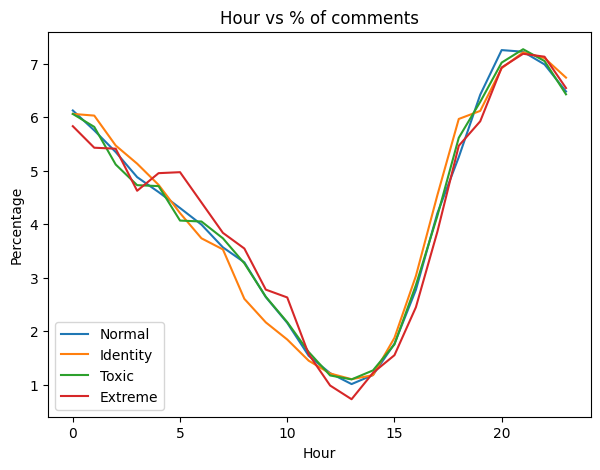

In [43]:
# creating plots

# creating label names dictionary
label_names = {
    0: 'Normal',
    1: 'Identity',
    2: 'Toxic',
    3: 'Extreme'
}

# creating plot:
plt.figure(figsize=(7, 5))

# hour-wise distribution
print("\nHOUR-WISE DISTRIBUTION\n")

# looping through each label
for label in [0, 1, 2, 3]:

    print("\n--- LABEL:", label_names[label], "(", label, ") ---")

    # filtering data for this label
    label_data = train[train['label'] == label]

    # counting comments per hour
    hourly_counts = label_data.groupby('hour').size()

    print("\nRaw Counts (Number of comments per hour):")
    print(hourly_counts)

    # calculating total comments
    total_comments = hourly_counts.sum()

    # converting counts to percentage
    hourly_percent = (hourly_counts / total_comments) * 100

    print("\nPercentage Distribution:")
    print(hourly_percent)

    # plotting simple line (no fancy styling)
    plt.plot(hourly_percent.index, hourly_percent.values, label=label_names[label])

# setting simple title and labels (removing bold/fancy stuff)
plt.title('Hour vs % of comments')
plt.xlabel('Hour')
plt.ylabel('Percentage')

# showing legend
plt.legend()

# showing plot
plt.show()

## Data preparation for modelling
the dataset is prepared for machine learning by splitting the data and transforming features.

### separating target variable from input features

In [44]:
'''X=train.drop(columns=['label'])
y=train['label']'''

"X=train.drop(columns=['label'])\ny=train['label']"

### removing unnecessary features

In [45]:
'''train = train.drop(columns=['gender', 'race', 'religion'])
test = test.drop(columns=['gender', 'race', 'religion'])'''

"train = train.drop(columns=['gender', 'race', 'religion'])\ntest = test.drop(columns=['gender', 'race', 'religion'])"

Columns such as gender, race, and religion were dropped due to a large number of missing values and limited relevance to the current modeling approach.

### Train-validation Split
the dataset is split into training and validation sets before applying any transformations to avoid data leakage.

In [ ]:
'''from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)'''

## Feature Engineering
new features are created and existing features are transformed to make them suitable for machine learning models.

### Text feature engineering
the comment text is converted into numerical form using TF-IDF(Term Frequency - Inverse Document Frequency), which helps capture the importance of words in the dataset.

In [ ]:
'''train['text_length'] = train['comment'].apply(len)
train['word_count'] = train['comment'].apply(lambda x: len(x.split()))
train['exclamation_count'] = train['comment'].apply(lambda x: x.count('!'))
train['question_count'] = train['comment'].apply(lambda x: x.count('?'))'''

In [ ]:
'''import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text'''

In [ ]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english', min_df=5)'''

In [ ]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=70000, ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)'''

In [ ]:
'''X_train_text=tfidf.fit_transform(X_train['comment'])
X_val_text=tfidf.transform(X_val['comment'])'''

TF-IDF helps convert textual data into numerical vectors by considering both word frequency and importance across the dataset.

N-grams are used to capture phrases and context instead of just individual words.

### Numerical Feature Scaling

Numerical features are scaled to bring them to a similar range, which helps improve model performance.

In [ ]:
#numeric_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']

In [ ]:
'''from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_val_num=scaler.transform(X_val[numeric_cols])'''

Scaling ensures that features with larger values do not dominate the model during training.

### Combine features

Text and numerical features are combined into a single feature matrix.

In [ ]:
'''from scipy.sparse import hstack
X_train_comb = hstack([X_train_text, X_train_num])
X_val_comb=hstack([X_val_text, X_val_num])'''

Combining both text and numerical features allows the model to learn from multiple types of information simultaneously.

# Model building

## Logistic Regression

Logistic Regression is used as a baseline model as it performs well on high-dimensional sparse data such as TF-IDF features.

In [ ]:
'''from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1)
lr_model.fit(X_train_comb, y_train)
y_pred_lr = lr_model.predict(X_val_comb)
print(classification_report(y_val, y_pred_lr))
macro_f1_lr = f1_score(y_val, y_pred_lr, average='macro')
print("Macro F1:", macro_f1_lr)'''

    when max_features=20000
    precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.68      0.84      0.75      3183
           2       0.88      0.86      0.87     12488
           3       0.46      0.77      0.58      1094

    accuracy                           0.90     39600
    macro avg       0.75      0.85      0.79     39600
    weighted avg    0.91      0.90      0.90     39600

Macro F1: 0.7885851620232864

    when max_features=50000

    precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.69      0.84      0.76      3183
           2       0.88      0.86      0.87     12488
           3       0.49      0.75      0.59      1094

    accuracy                           0.90     39600
    macro avg       0.76      0.85      0.79     39600
    weighted avg    0.91      0.90      0.90     39600

Macro F1: 0.7943552852157307

    when max_features=60000

    precision  recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.69      0.84      0.76      3183
           2       0.88      0.87      0.87     12488
           3       0.49      0.75      0.60      1094

    accuracy                           0.90     39600
    macro avg      0.76      0.85      0.80     39600
    weighted avg   0.91      0.90      0.90     39600

Macro F1: 0.7958418933964213

    when max_features=70000
    precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.69      0.83      0.76      3183
           2       0.88      0.87      0.87     12488
           3       0.53      0.75      0.62      1094

    accuracy                            0.90     39600
    macro avg       0.77      0.85      0.80     39600
    weighted avg    0.91      0.90      0.90     39600

Macro F1: 0.8007759492124302

## SGD Classifier

SGD is an efficient optimization-based model suitable for large datasets.

In [ ]:
'''from sklearn.linear_model import SGDClassifier
sgd_model = SGDClassifier(alpha=0.0001, max_iter=1000, random_state=42)
sgd_model.fit(X_train_comb, y_train)
y_pred_sgd = sgd_model.predict(X_val_comb)
print(classification_report(y_val, y_pred_sgd))
macro_f1_sgd = f1_score(y_val, y_pred_sgd, average='macro')
print("Macro F1:", macro_f1_sgd)'''

In [ ]:
'''def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    return macro_f1'''

In [ ]:
'''sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, class_weight='balanced', random_state=42)
sgd_macro_f1 = evaluate_model(sgd_model, X_train_comb, y_train, X_val_comb, y_val)
print("SGD Macro F1:", sgd_macro_f1)'''

with max_features=20000 and n_grams=(1,2): SGD Macro F1: 0.7746744460035615

with max_features=70000 and n_grams=(1,2): SGD Macro F1: 0.765788520036581

## Naive Bayes

Naive Bayes is commonly used for text classification due to its simplicity and speed.

In [ ]:
'''from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_text, y_train)
y_pred_nb = nb_model.predict(X_val_text)
print(classification_report(y_val, y_pred_nb))
macro_f1_nb = f1_score(y_val, y_pred_nb, average='macro')
print("Macro F1:", macro_f1_nb)'''

    precision    recall  f1-score   support

           0       0.69      0.93      0.79     22835
           1       0.80      0.24      0.37      3183
           2       0.74      0.49      0.59     12488
           3       0.92      0.01      0.02      1094

    accuracy                            0.71     39600
    macro avg       0.79      0.41      0.44     39600
    weighted avg    0.72      0.71      0.67     39600

Macro F1: 0.44104552727167806

### Support Vector Machine (LinearSVC)

SVM is effective in high-dimensional spaces and works well with text data.

In [ ]:
'''from sklearn.svm import LinearSVC
svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_train_comb, y_train)
y_pred_svm = svm_model.predict(X_val_comb)
print(classification_report(y_val, y_pred_svm))
macro_f1_svm = f1_score(y_val, y_pred_svm, average='macro')
print("Macro F1:", macro_f1_svm)'''

    precision    recall  f1-score   support

           0       0.84      0.85      0.84     22835
           1       0.64      0.69      0.66      3183
           2       0.76      0.72      0.74     12488
           3       0.50      0.50      0.50      1094

    accuracy                           0.79     39600
    macro avg       0.69      0.69      0.69     39600
    weighted avg    0.79      0.79      0.79     39600

Macro F1: 0.6877975451081544

## Model comparison 

| Model               | Accuracy | Macro F1 | Key Issue              |
| ------------------- | -------- | -------- | ---------------------- |
| Logistic Regression | 0.79     | 0.80     | class 3 weak           |
| SGD                 | 0.73     | 0.77     | class 2 & 3 weak       |
| Naive Bayes         | 0.71     | 0.44     | class 3 almost ignored |
| LinearSVC           | 0.79     | 0.68     | best balance           |


- Logistic Regression and SGD performed the best overall with good accuracy and balanced performance.
- LinearSVC showed lower performance, especially for minority classes.
- Naive Bayes struggled to correctly predict class 3, showing very low recall.

Overall, SGD and Logistic Regression were the most reliable models for this task.

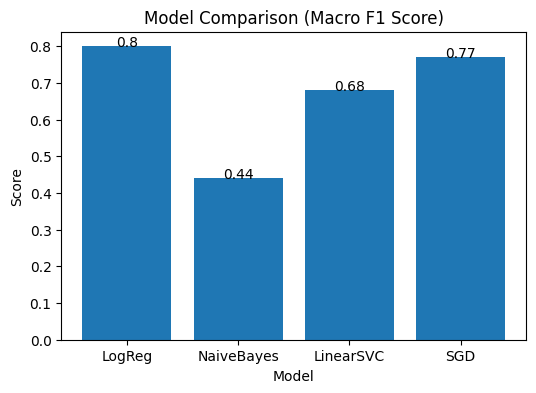

In [54]:
models = ['LogReg', 'NaiveBayes', 'LinearSVC', 'SGD']
scores = [0.80, 0.44, 0.68, 0.77] 
plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.title('Model Comparison (Macro F1 Score)')
plt.xlabel('Model')
plt.ylabel('Score')

# adding values on bars
for i in range(len(scores)):
    plt.text(i, scores[i], round(scores[i], 3), ha='center')

plt.show()

# Hyperparameter Tuning
Different values of C(for Logistic regression) and alpha (for SGD) were tested to improve performance.

In [ ]:
'''C_values = [0.01, 0.1, 1, 10, 0.5, 2, 5]

for C in C_values:
    lr_model = LogisticRegression(C=C, max_iter=2000, class_weight='balanced', n_jobs=-1)
    macro_f1 = evaluate_model(lr_model, X_train_comb, y_train, X_val_comb, y_val)
    print(f"C: {C} | Macro F1: {macro_f1}")'''

C: 0.01 | Macro F1: 0.6976232573805727--> lower performance

C: 0.1 | Macro F1: 0.7715061443058313--> improved

C: 1 | Macro F1: 0.8007759492124302--> improved (can be used)

C: 10 | Macro F1: 0.7904971510370159 -->slight drop

C: 0.5 | Macro F1: 0.7976442998256417--> improved

C: 2 | Macro F1: 0.8025596881027243 --> best performance (can be used)

C: 5 | Macro F1: 0.7978192370806935-->slight drop

In [ ]:
'''alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5]

for alpha in alphas:
    sgd_model = SGDClassifier(loss='log_loss', alpha=alpha, max_iter=1000, class_weight='balanced', random_state=42)
    macro_f1 = evaluate_model(sgd_model, X_train_comb, y_train, X_val_comb, y_val)
    print(f"Alpha: {alpha} | Macro F1: {macro_f1}")'''

Alpha: 0.0001 | Macro F1: 0.765788520036581 --> best

Alpha: 0.001 | Macro F1: 0.6189147818372077

Alpha: 0.01 | Macro F1: 0.4884045985026918

Alpha: 0.1 | Macro F1: 0.3411269295650535 --> worst

Alpha: 0.5 | Macro F1: 0.3475699228095314

Alpha: 1 | Macro F1: 0.35307355473712515

Alpha: 2 | Macro F1: 0.3479362821323432

Alpha: 5 | Macro F1: 0.34463829713653055

Logistic regression gave the highest F1-score amomg all i.e. Macro F1: 0.8007759492124302 with max_features=70000 and C=1.

# Dimensionality Reduction


In [ ]:
'''from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=300)
X_train_reduced = svd.fit_transform(X_train_text)
X_val_reduced = svd.transform(X_val_text)
model = LogisticRegression(C=1, class_weight='balanced', max_iter=2000)
model.fit(X_train_reduced, y_train)
y_pred = model.predict(X_val_reduced)
print(classification_report(y_val, y_pred))
macro_f1 = f1_score(y_val, y_pred, average='macro')
print("Macro F1:", macro_f1)'''

        precision    recall  f1-score   support

           0       0.77      0.57      0.65     22835
           1       0.46      0.74      0.57      3183
           2       0.54      0.54      0.54     12488
           3       0.15      0.71      0.24      1094

    accuracy                            0.58     39600
    macro avg       0.48      0.64      0.50     39600
    weighted avg    0.66      0.58      0.60     39600

Macro F1: 0.5026008492019399

Applying TruncatedSVD reduced the dimensionality but also caused a drop in classification performance as well as Macro F1 score. Therefore, the original TF-IDF representation will be retained for the final model.

In [ ]:
#trying KNeighborsClassifier

'''from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_text, y_train)
y_pred_knn = knn.predict(X_val_text)
print(classification_report(y_val, y_pred_knn))
macro_f1 = f1_score(y_val, y_pred_knn, average='macro')
print("Macro F1:", macro_f1)'''

    precision    recall  f1-score   support

           0       0.58      0.98      0.73     22835
           1       0.73      0.01      0.01      3183
           2       0.44      0.03      0.06     12488
           3       0.72      0.03      0.05      1094

    accuracy                           0.58     39600
    macro avg       0.62      0.26      0.21     39600
    weighted avg    0.55      0.58      0.44     39600

Macro F1: 0.2122392710844995

# boosting & multi-layer perceptron

In [ ]:
'''from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, objective='multi:softmax', num_class=4)
xgb_model.fit(X_train_text, y_train)
y_pred_xgb = xgb_model.predict(X_val_text)
print(classification_report(y_val, y_pred_xgb))
macro_f1 = f1_score(y_val, y_pred_xgb, average='macro')
print("Macro F1:", macro_f1)'''

    precision    recall  f1-score   support

           0       0.74      0.94      0.82     22835
           1       0.71      0.59      0.64      3183
           2       0.84      0.51      0.64     12488
           3       0.64      0.23      0.34      1094

    accuracy                            0.75     39600
    macro avg       0.73      0.57      0.61     39600
    weighted avg    0.77      0.75      0.74     39600

In [ ]:
'''from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=20, random_state=42)
mlp.fit(X_train_text, y_train)
y_pred_mlp = mlp.predict(X_val_text)
print(classification_report(y_val, y_pred_mlp))
macro_f1 = f1_score(y_val, y_pred_mlp, average='macro')
print("Macro F1:", macro_f1)'''

    precision    recall  f1-score   support

           0       0.59      0.97      0.73     22835
           1       0.72      0.04      0.07      3183
           2       0.53      0.06      0.11     12488
           3       0.64      0.07      0.12      1094

    accuracy                           0.58     39600
    macro avg       0.62      0.28      0.26     39600
    weighted avg    0.58      0.58      0.47     39600


### feature selection

In [ ]:
'''from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(chi2, k=10000)
X_train_selected = selector.fit_transform(X_train_text, y_train)
X_val_selected = selector.transform(X_val_text)
model = LogisticRegression(C=1, class_weight='balanced', max_iter=2000)
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_val_selected)
print(classification_report(y_val, y_pred))'''



Feature selection was performed using the Chi-square statistical test to select the most discriminative features for classification.

    precision    recall  f1-score   support

           0       0.86      0.78      0.82     22835
           1       0.56      0.81      0.66      3183
           2       0.76      0.71      0.74     12488
           3       0.30      0.73      0.42      1094

    accuracy                           0.76     39600
    macro avg       0.62      0.76      0.66     39600
    weighted avg    0.79      0.76      0.77     39600

## Final Model

Based on the comparison of different models, Logistic Regression and LinearSVC showed the best performance.

To further improve performance, especially for minority classes, class weights were introduced in Logistic Regression.

This helps the model pay more attention to underrepresented classes and improves recall for those classes.

In [ ]:
'''final_model = LogisticRegression(C=1, class_weight={0:1, 1:2, 2:1, 3:4}, max_iter=2000, n_jobs=-1)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_val)
print(classification_report(y_val, y_pred_final))'''

Class  |	Affect after assigning weights

0	   |    Still strong (expected, lots of data)

1	   |    Improved balance

2		|   Slight drop but stable

3		|   Huge improvement (main goal achieved)

After applying class weights, the performance for minority classes improved significantly. class 3 recall increased from a very low value to around 0.51, indicating that the model is now able to better identify underrepresented classes.

The final model provides a good balance across all classes and is suitable for final submission.

# Final Training and Kaggle Submission

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

In [ ]:
#ensuring the text is clean
train['comment']= train['comment'].fillna("").astype(str)
test['comment'] = test['comment'].fillna("").astype(str)

In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=70000, ngram_range=(1,2), stop_words='english', min_df=5)
X_text = tfidf.fit_transform(train['comment'])
X_test_text = tfidf.transform(test['comment'])

# Numeric features
numeric_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3']
scaler = StandardScaler()
X_numeric = scaler.fit_transform(train[numeric_cols])
X_test_numeric = scaler.transform(test[numeric_cols])

# Combine
X_combined = hstack([X_text, X_numeric])
X_test_combined = hstack([X_test_text, X_test_numeric])

# Train model
model = LogisticRegression(C=2, class_weight={0:1, 1:2, 2:1, 3:4}, max_iter=2000, n_jobs=-1)
model.fit(X_combined, train['label'])

# Predict
preds = model.predict(X_test_combined)

# Submission
submission = pd.DataFrame({"ID": range(1, len(preds)+1), "label": preds})
submission.to_csv("submission.csv", index=False)
print("submission.csv created successfully")


# Additional Experiments and Further Improvements

After obtaining a submission that crossed the competition cutoff, I continued experimenting with alternative configurations to explore potential performance improvements.

These experiments included:

* Testing Logistic Regression with different values of the regularization parameter (C)
* Exploring alternative TF-IDF vectorizer configurations
* Creating additional engineered features based on text, identity, and temporal information
* Evaluating whether these changes could improve leaderboard performance

The cells below are exploratory experiments conducted after the primary model had been finalized and submitted. While these experiments did not consistently improve leaderboard scores, they helped me better understand feature engineering, model tuning, and the trade-offs involved in text classification.

## EXPERIMENTED submitting logistic regression model with c=1

In [ ]:
#test.isna().sum()

In [ ]:
#test['comment'] = test['comment'].fillna("").astype(str)

In [ ]:
# Recreate full TF-IDF using entire training data
'''tfidf_final = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english', min_df=5)
X_text_full = tfidf_final.fit_transform(train['comment'])
X_text_test = tfidf_final.transform(test['comment'])'''

In [ ]:
'''numeric_features = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
scaler_final = StandardScaler()
X_numeric_full = scaler_final.fit_transform(train[numeric_features])
X_numeric_test = scaler_final.transform(test[numeric_features])'''

In [ ]:
'''from scipy.sparse import csr_matrix, hstack

X_numeric_full_sparse = csr_matrix(X_numeric_full)
X_numeric_test_sparse = csr_matrix(X_numeric_test)

X_full_combined = hstack([X_text_full, X_numeric_full_sparse])
X_test_combined = hstack([X_text_test, X_numeric_test_sparse])'''

In [ ]:
'''final_model = LogisticRegression(C=1, max_iter=2000, class_weight='balanced', n_jobs=-1)
final_model.fit(X_full_combined, train['label'])'''

In [ ]:
'''test_predictions = final_model.predict(X_test_combined)'''

In [ ]:
'''submission = pd.DataFrame({'ID': range(1, len(test_predictions) + 1), 'label': test_predictions})
submission.to_csv('submission.csv', index=False)'''

## experimenting with vectorizer

In [ ]:
'''tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    stop_words='english',
    min_df=5
)'''

In [ ]:
'''X_train_text = tfidf.fit_transform(X_train['comment'])
X_val_text = tfidf.transform(X_val['comment'])'''

In [ ]:
'''X_train_combined = hstack([X_train_text, X_train_numeric])
X_val_combined = hstack([X_val_text, X_val_numeric])'''

In [ ]:
'''model = LogisticRegression(
    C=1,
    class_weight='balanced',
    max_iter=2000,
    n_jobs=-1
)

model.fit(X_train_combined, y_train)

y_pred = model.predict(X_val_combined)

print(classification_report(y_val, y_pred))'''

precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.68      0.84      0.75      3183
           2       0.88      0.86      0.87     12488
           3       0.47      0.76      0.58      1094

    accuracy                            0.90     39600
    macro avg       0.75      0.85      0.79     39600
    weighted avg    0.91      0.90      0.90     39600


In [ ]:
'''model = LogisticRegression(
    C=1,
    class_weight={0:1, 1:2, 2:1, 3:4},
    max_iter=2000,
    n_jobs=-1
)

model.fit(X_train_combined, y_train)

y_pred = model.predict(X_val_combined)

print(classification_report(y_val, y_pred))'''

precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.74      0.78      0.76      3183
           2       0.87      0.89      0.88     12488
           3       0.60      0.66      0.63      1094

    accuracy                            0.91     39600
    macro avg       0.80      0.82      0.81     39600
    weighted avg    0.91      0.91      0.91     39600

The weighted configuration improved validation performance, particularly for minority classes.
This shows my intuition about class imbalance was correct.

class_weight={0:1, 1:2, 2:1, 3:4}

class 3 errors are penalized more.
the model tries harder to detect minority comments.
This improved recall and F1 for class 3.

In [ ]:
'''from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=2,
    class_weight={0:1, 1:2, 2:1, 3:4},
    max_iter=2000,
    n_jobs=-1
)

model.fit(X_train_text, y_train)'''

In [ ]:
'''from sklearn.metrics import classification_report, f1_score

y_val_pred = model.predict(X_val_text)

print("Validation Results:\n")
print(classification_report(y_val, y_val_pred))

macro_f1 = f1_score(y_val, y_val_pred, average='macro')
print("Macro F1:", macro_f1)'''

Validation Results (both same when used num+text and when only used text):

              precision    recall  f1-score   support

           0       0.81      0.89      0.85     22835
           1       0.68      0.67      0.67      3183
           2       0.80      0.66      0.73     12488
           3       0.51      0.51      0.51      1094

    accuracy                            0.79     39600
    macro avg        0.70      0.68      0.69     39600
    weighted avg     0.79      0.79      0.79     39600

Macro F1: 0.6900839580488798

## Further Feature Engineering Experiments

In [46]:
# loading data
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# filling missing comments with empty text
train['comment'] = train['comment'].fillna('')
test['comment'] = test['comment'].fillna('')

# filling missing values in categorical columns
for col in ['race', 'religion', 'gender']:
    train[col] = train[col].fillna('missing')
    test[col] = test[col].fillna('missing')

# converting disability column to string
train['disability'] = train['disability'].astype(str)
test['disability'] = test['disability'].astype(str)

# printing message
print("data loaded and missing values handled")
print("now creating features...")

data loaded and missing values handled
now creating features...


In [47]:
# creating datetime features

print("creating datetime features")

# applying same steps to both train and test
for df in [train, test]:
    
    # converting to datetime
    df['created_date'] = pd.to_datetime(df['created_date'])
    
    # extracting hour, day, month
    df['hour'] = df['created_date'].dt.hour
    df['dayofweek'] = df['created_date'].dt.dayofweek
    df['month'] = df['created_date'].dt.month
    
    # creating night feature (8pm to 11pm)
    df['is_night'] = df['hour'].between(20, 23)
    df['is_night'] = df['is_night'].astype(int)
    
    # creating weekend feature (sat, sun)
    df['is_weekend'] = df['dayofweek'].isin([5, 6])
    df['is_weekend'] = df['is_weekend'].astype(int)

# printing simple info
print("hour, dayofweek, month created")
print("is_night and is_weekend created")

# showing sample
print(train[['hour','dayofweek','month','is_night','is_weekend']].head(3))

creating datetime features
hour, dayofweek, month created
is_night and is_weekend created
   hour  dayofweek  month  is_night  is_weekend
0     8          3      1         0           0
1    21          6      3         1           1
2    20          2      4         1           0


In [48]:
# creating identity features
print("creating identity features")

# applying same steps to train and test
for df in [train, test]:
    
    # creating flag if identity info is present
    df['identity_present'] = (df['race'] != 'missing')
    df['identity_present'] = df['identity_present'].astype(int)
    
    # checking if specific race is mentioned
    df['specific_race'] = ~df['race'].isin(['missing', 'none'])
    df['specific_race'] = df['specific_race'].astype(int)
    
    # checking if specific religion is mentioned
    df['specific_religion'] = ~df['religion'].isin(['missing', 'none'])
    df['specific_religion'] = df['specific_religion'].astype(int)
    
    # checking if specific gender is mentioned
    df['specific_gender'] = ~df['gender'].isin(['missing', 'none'])
    df['specific_gender'] = df['specific_gender'].astype(int)

# printing simple info
print("identity_present, specific_race, specific_religion, specific_gender created")

# verifying effect on label 1
subset = train[train['identity_present'] == 1]

print("label distribution when identity_present = 1:")
print(subset['label'].value_counts(normalize=True).sort_index() * 100)

creating identity features
identity_present, specific_race, specific_religion, specific_gender created
label distribution when identity_present = 1:
label
0    44.994960
1    25.121251
2    27.757384
3     2.126405
Name: proportion, dtype: float64


In [51]:
# creating text features

print("creating text features")

# list of important words
violent_words = ['kill','killing','killed','shoot','shot','shooting', 'death','dead','die',
                 'murder','bomb','attack','destroy','hang','execute','genocide']

identity_words = ['white','black','muslim','islam','jew','jewish','christian','women',
                  'female','male','gay','lesbian','racist','racism','transgender','gender',
                  'race']
toxic_words = ['idiot','stupid','moron','liar','fool','dumb','trash','garbage','pathetic',
               'disgusting','corrupt','criminal','hate','loser']

def create_text_features(df):
    
    # converting text to lowercase
    text = df['comment'].str.lower()
    
    # counting words and characters
    df['word_count'] = df['comment'].str.split().str.len()
    df['char_count'] = df['comment'].str.len()
    
    # calculating lexical diversity (simple loop)
    diversity_list = []
    for x in df['comment']:
        words = str(x).lower().split()
        unique_words = set(words)
        value = len(unique_words) / (len(words) + 1)
        diversity_list.append(value)
    
    df['lexical_diversity'] = diversity_list
    
    # counting violent words
    violent_counts = []
    for x in df['comment']:
        count = 0
        text_x = str(x).lower()
        for w in violent_words:
            if w in text_x:
                count += 1
        violent_counts.append(count)
    
    df['violent_word_count'] = violent_counts
    
    # counting identity words
    identity_counts = []
    for x in df['comment']:
        count = 0
        text_x = str(x).lower()
        for w in identity_words:
            if w in text_x:
                count += 1
        identity_counts.append(count)
    
    df['identity_word_count'] = identity_counts
    
    # counting toxic words
    toxic_counts = []
    for x in df['comment']:
        count = 0
        text_x = str(x).lower()
        for w in toxic_words:
            if w in text_x:
                count += 1
        toxic_counts.append(count)
    
    df['toxic_word_count'] = toxic_counts
    
    # counting capital words
    caps_list = []
    for x in df['comment']:
        caps = re.findall(r'[A-Z]{2,}', str(x))
        caps_list.append(len(caps))
    
    df['caps_count'] = caps_list
    
    # counting exclamation marks
    df['exclaim_count'] = df['comment'].str.count('!')
    
    # counting question marks
    df['question_count'] = df['comment'].str.count(r'\?')
    
    return df


# applying to train and test
print("applying to train")
train = create_text_features(train)

print("applying to test")
test = create_text_features(test)


# printing simple info
print("text features created:")
print("word_count, char_count, lexical_diversity")
print("violent_word_count, identity_word_count, toxic_word_count")
print("caps_count, exclaim_count, question_count")

creating text features
applying to train
applying to test
text features created:
word_count, char_count, lexical_diversity
violent_word_count, identity_word_count, toxic_word_count
caps_count, exclaim_count, question_count


In [ ]:
# visualizing new features 
# defining label names
label_names = ['Normal', 'Identity', 'Toxic', 'Extreme']

# selecting fewer important features 
features_to_plot = ['word_count', 'violent_word_count', 'identity_word_count']

# plotting one by one
for feat in features_to_plot:
    plt.figure(figsize=(5, 4))
    
    # calculating mean values
    means = train.groupby('label')[feat].mean()
    
    # plotting
    plt.bar(label_names, means.values)
    
    # clear title
    plt.title('Average ' + feat + ' per Label')
    plt.xlabel('Category')
    plt.ylabel('Average Value')
    
    # adding values
    for i in range(len(means.values)):
        val = round(means.values[i], 2)
        plt.text(i, val, val, ha='center')
    
    plt.show()

for the 1st plot, average word count, most categories have similar lengths, except for the extreme category, which has shorter comments.

extreme category has the highest average violent word count.

This indicates that violent language is a strong signal for identifying extreme comments.

the identity category has the highest identity word count.


# Project Outcome

The final solution used TF-IDF vectorization combined with Logistic Regression.

Multiple models including Naive Bayes, SGD Classifier, Support Vector Machine (SVM), KNN, dimensionality reduction techniques, feature selection methods, and ensemble approaches were evaluated and compared.

Logistic Regression consistently delivered the best balance between performance and computational efficiency. Additional improvements were achieved through hyperparameter tuning and class weighting to address class imbalance.

The project successfully met the competition requirements and produced a submission that crossed the required cutoff score.


# Key Learnings

Through this project, I learned:

* How to perform exploratory data analysis on large text datasets
* The importance of feature engineering in NLP tasks
* How TF-IDF converts text into numerical representations
* How different machine learning algorithms behave on sparse text data
* The impact of hyperparameter tuning on model performance
* The challenges of handling class imbalance in multi-class classification problems
* How to evaluate models using Precision, Recall, and Macro F1-score
* The iterative nature of machine learning experimentation
